# ICS 235 Assignment 1
## Exploratory Data Analysis and the k-NN Classifier
# <span style="color:red">Due: 11:59 PM on Wednesday, September 23</span>

## Instructions

1. Name your notebook file using your last and first name.
    - For example, if your name is Harry Potter, rename the notebook file as `PotterHarry_1.ipynb` (the number at the end is the assignment number).
2. Only use the `.ipynb` file extension. Other formats (`.rtf`, `.zip`, `.docx`, `.pdf`) are not accepted.
3. The data file will be available to the instructor and the TA, so there is no need to upload it. Make sure you use the same filename given in the assignment.
4. Save the data file in your **working directory**.
5. **Do not modify or delete the provided code.**
6. Clean your code before submission.
    - If needed, provide clear documentation describing the purpose and use of every class or function you write.
    - Your submission should **show only the required outputs**.
7. **<font color='red'>IMPORTANT:</font>** Before submitting your homework:
   - Save the notebook.
   - Restart the kernel to clear its memory and **run the whole notebook top to bottom.** (`Kernel → Restart & Run All Cells`).
   - Confirm every cell completes without error and all outputs are visible.
8. Write your full name in the cell below.


### AI tools

You may use AI coding assistants as a learning aid, but **you must understand and be able to
explain every line you submit**. You may be asked to do so. Submitting code you cannot explain
is an academic integrity violation.
***

## Your Name: Denny Huang
***

# Getting Started

## About the data

This assignment uses `pa1_oahu_housing.csv`, a table of residential properties on Oʻahu.

> **This dataset is synthetic.** It was generated for instructional use in this course. The regions and the general shape of the relationships are realistic, but no row corresponds to a real property, and you should not draw conclusions about the actual Hawaiʻi housing market from it.

The table has **420 rows** and **9 columns**:

| Column | Description |
|---|---|
| `region` | District of Oʻahu (Honolulu, Kailua, Kaneohe, Kapolei, Mililani, North Shore) |
| `dist_downtown_km` | Straight-line distance from downtown Honolulu, in kilometers |
| `elevation_m` | Elevation of the property above sea level, in meters |
| `lot_sqft` | Total lot area, in square feet |
| `bedrooms` | Number of bedrooms |
| `bathrooms` | Number of bathrooms (half-baths appear as `.5`) |
| `age_years` | Age of the structure, in years |
| `living_sqft` | Interior living area, in square feet |
| `price_tier` | **The target.** One of `affordable`, `mid`, `luxury` |

## The task

Your job is to predict a property's `price_tier` from its other attributes, using the **k-Nearest Neighbors (k-NN)** classifier. Along the way you will do the work that often comes *before* a model: inspecting the data, finding its defects, and understanding why a distance-based algorithm cares so much about the units your features are measured in.

Download `pa1_oahu_housing.csv` from Lamaku and save the file in your **working directory**.

## Importing packages

Run the following cell. If any of these libraries are not installed on your machine, install
them with `pip install <name>` or `conda install <name>`.

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility: use this constant everywhere a random_state is required.
RANDOM_STATE = 42

## Loading the dataset

We load the dataset into a `pandas.DataFrame` using `pd.read_csv()`.

In [42]:
housing = pd.read_csv("pa1_oahu_housing.csv")

Let's confirm the file parsed correctly by looking at the first five rows.

In [43]:
housing.head()

,region,dist_downtown_km,elevation_m,lot_sqft,bedrooms,bathrooms,age_years,living_sqft,price_tier
0,Kaneohe,16.8,49,5608,3,3,29.0,1995.0,mid
1,Kaneohe,17.9,30,5466,3,3,35.0,NaN,mid
2,Honolulu,3.4,0,3979,3,2,33.0,2017.0,mid
3,Honolulu,6.2,25,4769,4,3,38.0,3115.0,luxury
4,Mililani,24.0,96,5322,2,2,41.0,1979.0,affordable


## A short refresher on pandas

You will need a few pandas operations throughout. Run the next three cells &mdash; they are here so you can copy the patterns later if needed.

**Selecting one column** gives you a `pandas.Series`:

In [44]:
living_area = housing["living_sqft"]
print(type(living_area))
living_area.head()

<class 'pandas.Series'>


0    1995.0
1       NaN
2    2017.0
3    3115.0
4    1979.0
Name: living_sqft, dtype: float64

**Selecting several columns** (note the list inside the brackets) gives you a `DataFrame`:

In [45]:
size_columns = housing[["bedrooms", "bathrooms", "living_sqft"]]
size_columns.head()

,bedrooms,bathrooms,living_sqft
0,3,3,1995.0
1,3,3,NaN
2,3,2,2017.0
3,4,3,3115.0
4,2,2,1979.0


**Boolean masks** let you filter rows. Combine conditions with `&` (and) and `|` (or) — *not*
the Python keywords `and`/`or` — and parenthesize each condition:

In [46]:
big_and_close = housing[(housing["living_sqft"] > 3000) & (housing["dist_downtown_km"] < 10)]
print(f"{len(big_and_close)} properties are larger than 3000 sqft and within 10 km of downtown")

8 properties are larger than 3000 sqft and within 10 km of downtown


***
# Exercises

This assignment has **three parts**, worth 100 points total.

Write your answer wherever you see a *`# YOUR CODE`* comment in a code cell or a **`YOUR ANSWER:`** prompt in a markdown cell. Some cells already contain code to get you started — **do not modify the provided code**. The point value of each question is given in parentheses after the question text.

| Part | Topic | Points |
|---|---|---|
| 1 | Preliminary analysis and data quality | 35 |
| 2 | k-NN with scikit-learn: scaling and choosing *k* | 40 |
| 3 | Final evaluation and data story | 25 |

***
## Part 1: Preliminary Analysis and Data Quality (35 points)

Before fitting any model, find out what you actually have. The questions in this part cover some checks you should routinely perform when working with any new dataset.

### Question 1. Dataset structure (1 $\times$ 4 = 4 points)

1. Print the number of rows and the number of columns, as a readable sentence
   (e.g. `"The dataset has ___ rows and ___ columns."`).
2. Display the column names together with their data types and non-null counts.
   - Hint: `DataFrame.info()` does all of this in one call.
3. Display the **first 10 rows**.
4. In the answer cell below, state how many columns are **numerical** and how many are
   **categorical**, and identify which column is the **target**.

In [47]:
# YOUR CODE
rows, cols = housing.shape
print(f"This dataset has {rows} rows and {cols} columns")
print(housing.info())
housing.head(10)


This dataset has 420 rows and 9 columns
<class 'pandas.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   region            420 non-null    str    
 1   dist_downtown_km  420 non-null    float64
 2   elevation_m       420 non-null    int64  
 3   lot_sqft          420 non-null    int64  
 4   bedrooms          420 non-null    int64  
 5   bathrooms         420 non-null    int64  
 6   age_years         410 non-null    float64
 7   living_sqft       408 non-null    float64
 8   price_tier        420 non-null    str    
dtypes: float64(3), int64(4), str(2)
memory usage: 29.7 KB
None


,region,dist_downtown_km,elevation_m,lot_sqft,bedrooms,bathrooms,age_years,living_sqft,price_tier
0,Kaneohe,16.8,49,5608,3,3,29.0,1995.0,mid
1,Kaneohe,17.9,30,5466,3,3,35.0,NaN,mid
2,Honolulu,3.4,0,3979,3,2,33.0,2017.0,mid
3,Honolulu,6.2,25,4769,4,3,38.0,3115.0,luxury
4,Mililani,24.0,96,5322,2,2,41.0,1979.0,affordable
5,Kapolei,35.7,29,3702,4,4,12.0,3358.0,luxury
6,Honolulu,1.9,21,4823,3,2,51.0,2255.0,mid
7,Honolulu,0.5,43,3472,3,2,NaN,1898.0,mid
8,Mililani,20.4,103,8290,3,3,35.0,2524.0,luxury
9,Honolulu,5.9,13,5624,3,3,43.0,2412.0,mid


**YOUR ANSWER (Q1.4):**

Categorical: 2 categorical columns: region, price_tier <br>
Numerical: 7 numerical columns: dist_downtown_km, elevation_m, lot_sqft, bedrooms, bathrooms, age_years, living_sqft <br>
Target: price_tier

### Question 2. The target distribution and the baseline you must beat (1 + 1 + 3 + 3 = 8 points)

1. Print how many properties fall into each `price_tier`.
2. Print the same information as **proportions** rather than counts. Do not hardcode the numbers from Problem 1 to calculate the proportions. Display the proportions to three decimal places (e.g., 0.234).<br>
   - Hint: Check whether the parameters of the function that you used in Problem 1 can help.
3. A trivial "classifier" could ignore every feature and always predict the **most frequent class**. Compute that classifier's *accuracy* on this dataset **in code** (do not just state it) and print it.
4. In the answer cell, explain what this number means and why every model you build later has to be compared against it.

In [48]:
# YOUR CODE
properties_by_tier = housing['price_tier'].value_counts()
print(properties_by_tier)

properties_by_tier = housing['price_tier'].value_counts(normalize=True)
print(properties_by_tier)

properties_by_tier = housing['price_tier'].value_counts(normalize=True).max()
print(f"Accuracy: {properties_by_tier}")



price_tier
mid           140
luxury        140
affordable    140
Name: count, dtype: int64
price_tier
mid           0.333333
luxury        0.333333
affordable    0.333333
Name: proportion, dtype: float64
Accuracy: 0.3333333333333333


>**YOUR ANSWER (Q2.4):** This number means that if we ignored every feature and always predicted the most frequent class, we would still be right 33.33% of the time. Every model that is built later has to be compared against it because this the minimum accuracy any model that is built should beat.
>
>

### Question 3. Missing values (1 + 2 + 2 + 3 = 8 points)

1. Print the number of missing values in each column.
2. Print the **percentage** of missing values, showing *only the columns that actually have missing data*.
   - Hint: `DataFrame.isnull().sum()` counts them; dividing by `len(df)` converts to a fraction.
3. Compute and print how many **rows** contain at least one missing value, and what percentage of the dataset that is.
   - Hint: `DataFrame.isnull().any(axis=1)` gives one boolean per row.
4. In the answer cell: if you dropped every row containing a missing value, how many rows would you be left with? When would this not be an acceptable trade-off, and what is the alternative? Justify your answer.

In [49]:
# YOUR CODE
missing_vals = housing.isna().sum()
print("Number of missing values in each column: ", missing_vals)

missing_vals_percent = (missing_vals / len(housing)) * 100
print("Percent of missing values in each column: ", missing_vals_percent)


atleast_one_missing_val_row = housing.loc[housing.isnull().any(axis=1)]
atleast_one_missing_val_row
# print(len(atleast_one_missing_val_row)) checks how many rows have at least 1 missing value



Number of missing values in each column:  region               0
dist_downtown_km     0
elevation_m          0
lot_sqft             0
bedrooms             0
bathrooms            0
age_years           10
living_sqft         12
price_tier           0
dtype: int64
Percent of missing values in each column:  region              0.000000
dist_downtown_km    0.000000
elevation_m         0.000000
lot_sqft            0.000000
bedrooms            0.000000
bathrooms           0.000000
age_years           2.380952
living_sqft         2.857143
price_tier          0.000000
dtype: float64


,region,dist_downtown_km,elevation_m,lot_sqft,bedrooms,bathrooms,age_years,living_sqft,price_tier
1,Kaneohe,17.9,30,5466,3,3,35.0,NaN,mid
7,Honolulu,0.5,43,3472,3,2,NaN,1898.0,mid
29,Honolulu,0.5,38,2712,3,2,39.0,NaN,mid
50,Mililani,23.4,86,6375,4,3,23.0,NaN,luxury
67,Kaneohe,20.3,49,8170,3,2,NaN,2328.0,mid
81,Kaneohe,23.5,28,5680,3,2,NaN,2115.0,mid
86,Kapolei,29.4,33,7689,2,2,NaN,1837.0,affordable
98,Mililani,22.3,103,6778,3,3,NaN,2532.0,luxury
102,Kailua,23.2,29,7015,4,4,NaN,3078.0,luxury
104,North Shore,50.2,22,10679,2,1,43.0,NaN,affordable


>**YOUR ANSWER (Q3.4):** There are 22 rows with at least 1 missing value, if we were to drop these rows, there would be 398 rows of data left (420-22). This would not be an acceptable trade-off if the dataset was small or if removing the 22 entries introduce bias. The alternative to dropping these rows with missing values is to impute the missing values with methods such as replacing missing values with the row's mean or median value.
>
>

### Question 4. Inconsistent categories (2 + 1 + 2 + 3 = 8 points)

Categorical columns typed by hand are almost never clean.

1. Print the value counts of the `region` column. How many **distinct labels** does pandas report?
2. Look carefully at the labels. Identify the ones that refer to the **same real region** but were recorded differently, and state which is which in the answer cell.
3. Create a **cleaned copy** of the DataFrame (call it `housing_clean`) in which the `region` values are standardized. Do **not** overwrite `housing`.
   - Hint: `.str.strip()` removes stray whitespace and `.str.title()` normalizes capitalization.
   - Re-print the value counts afterwards and report the new number of distinct labels.
4. In the answer cell: what could have gone wrong if you had skipped this step and applied one-hot encoding directly? In particular, what impact would this have on a distance-based model such as a k-NN classifier?

In [50]:
# YOUR CODE
region_val_counts = housing['region'].value_counts()
print(region_val_counts)
print("Number of distinct labels:", region_val_counts.shape[0]) # technically 6 because "Honolulu" and "North Shore" appear twice in different casings

housing_clean = housing.copy()
housing_clean['region'] = housing['region'].str.strip().str.title()

region_val_counts_clean = housing_clean['region'].value_counts()
print(region_val_counts_clean)
print("Number of distinct labels:", region_val_counts_clean.shape[0])


region
Honolulu       125
Kapolei         73
Kaneohe         62
Mililani        59
Kailua          55
North Shore     36
honolulu         6
North shore      4
Name: count, dtype: int64
Number of distinct labels: 8
region
Honolulu       131
Kapolei         73
Kaneohe         62
Mililani        59
Kailua          55
North Shore     40
Name: count, dtype: int64
Number of distinct labels: 6


>**YOUR ANSWER:**
>
>**Q4.2:** Honolulu shows up twice as "Honolulu" and "honolulu". North Shore also shows up twice as "North Shore" and "North shore"
>
>
>**Q4.4:** If I had skipped the step of standardizing the region values and applied one-hot encoding directly, we would have created 8 new columns, one for each distinct region before cleaning. This would make it so rows that belong to the same column would be split across multiple columns. This will also create 2 additional columns, increasing the dimensionality of the data. This increase in dimensionality would have a negative impact on a distance based model such as a KNN Classifier because of the curse of dimensionality. High dimensionality causes sparse and distance between points become meaningless, where everything becomes too far apart and equidistant.
>
>

### Question 5. Numeric ranges &mdash; a warning sign for k-NN (1 + 3 + 3 = 7 points)

1. Create a list named `numeric_features` containing the names of all numerical columns. Then, use this list to display the summary statistics for those columns in `housing_clean` using `describe()`.
2. Create and display a small DataFrame named `ranges` with one row for each numerical feature. It should contain the feature's **minimum**, **maximum**, and **range** (maximum − minimum), sorted from largest range to smallest.
   - Hint: Use `DataFrame.sort_values()` to sort by a specific column.
3. In the answer cell, identify the feature with the largest range and estimate how many times larger its range is than the smallest. Why should this concern you before running k-NN?

In [51]:
# YOUR CODE
numeric_features = ["dist_downtown_km", "elevation_m", "lot_sqft", "bedrooms", "bathrooms", "age_years", "living_sqft"]
housing_clean[numeric_features].describe()

ranges = pd.DataFrame({
    "min" : housing_clean[numeric_features].min(),
    "max" : housing_clean[numeric_features].max(),
    "range": housing_clean[numeric_features].max() - housing_clean[numeric_features].min()
})

ranges = ranges.sort_values("range", ascending=False)
ranges

,min,max,range
lot_sqft,1902.0,12500.0,10598.0
living_sqft,1064.0,3868.0,2804.0
elevation_m,0.0,115.0,115.0
age_years,0.0,72.0,72.0
dist_downtown_km,0.5,53.9,53.4
bedrooms,1.0,6.0,5.0
bathrooms,1.0,5.0,4.0


>**YOUR ANSWER (Q5.3):** The feature with the largest range was the lot_sqft feature, with a range of 10598. The feature with the smallest range is bathrooms, with a range of 4. The lot_sqft range is about 2650 time larger than the bathroom's range. This concerns me before running KNN because the feature with a much larger range will contribute more to the distance calculation than the feature that is much smaller. This can cause the KNN model to rely almost entirely on the lot_sqft feature when calculating the distance, and the bathroom feature (or smaller range features in general) will be completely disregarded.
>
>

***
## Part 2: k-NN with scikit-learn &mdash; Scaling and Choosing *k* (40 points)

Now we build the model. You will use scikit-learn's `KNeighborsClassifier` throughout &mdash; you are not asked to implement the algorithm yourself.

Everything goes inside a `Pipeline`, so that every transformation is refit from scratch on each cross-validation fold. Run the provided setup cell first.

In [52]:
# ============================ PROVIDED SETUP — do not modify ============================
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier

# Features = everything except the target. Target = price_tier.
X = housing_clean.drop(columns="price_tier")
y = housing_clean["price_tier"]

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

print(f"Training set: {X_train.shape[0]} rows    Test set: {X_test.shape[0]} rows")
print(f"Training class balance:\n{y_train.value_counts()}")
# =======================================================================================

Training set: 315 rows    Test set: 105 rows
Training class balance:
price_tier
luxury        105
mid           105
affordable    105
Name: count, dtype: int64


### Question 1. Build a leak-free preprocessing pipeline (4 + 2 + 2 + 3 = 11 points)

1. Build a `ColumnTransformer` named `preprocessor` that applies:
   - to the **numerical columns**: a `SimpleImputer(strategy="median")` followed by a `StandardScaler()` &mdash; chain them with a small inner `Pipeline`;
   - to the **`region` column**: a `OneHotEncoder(handle_unknown="ignore")`.
2. Wrap `preprocessor` and a `KNeighborsClassifier(n_neighbors=11)` in a single `Pipeline` named `knn_pipeline`.
3. Fit it on the training data and print its accuracy on **both** the training and the test set.
4. In the answer cell:
   - Explain why the imputer and the scaler must live **inside** the pipeline, rather than being applied to the whole DataFrame before splitting. What specifically would go wrong?
   - Explain what `handle_unknown="ignore"` protects you against.

In [53]:
# YOUR CODE
num_pipeline = Pipeline([
    ('imp', SimpleImputer(strategy="median")),
    ('sc', StandardScaler())
])
preprocessor = ColumnTransformer([
    ('num', num_pipeline, numeric_features),
    ('region', OneHotEncoder(handle_unknown="ignore"), ['region'])
])

knn_pipeline = Pipeline([
    ('prep', preprocessor),
    ('knn', KNeighborsClassifier(n_neighbors=11))
])

model_fit = knn_pipeline.fit(X_train, y_train)

train_accuracy = knn_pipeline.score(X_train, y_train)
test_accuracy = knn_pipeline.score(X_test, y_test)

print(f"Training accuracy: {train_accuracy:.4f}")
print(f"Test accuracy:     {test_accuracy:.4f}")

Training accuracy: 0.7556
Test accuracy:     0.6857


>**YOUR ANSWER (Q1.4):** The imputer and scaler must live inside the pipeline rather than being applied to the whole DataFrame before splitting because we only want to fit them on the training data. If the imputer and scaler is applied to the entire DataFrame before splitting, information from the test set will leak into the training process (data leakage). If we apply the imputer and scaler to the whole DF before splitting, the accuracy of the testing data will not be an accurate representation of how well the model generalized on unseen data because the test data had an influence on how the model was imputed and scaled. The handle_unknwon="ignore" parameter protects us against test data that has a categorical value that wasn't present in the training data.
>
>

### Question 2. Does scaling actually matter? (3 + 4 + 4 = 11 points)

In Part 1 you noticed that `lot_sqft` has a range roughly 2,650× larger than `bathrooms`. Now
measure what that does to the model.

1. Build a second pipeline, `knn_pipeline_unscaled`, identical to the first **except that the `StandardScaler` step is removed** (keep the imputer and the one-hot encoder).
2. For **both** pipelines, report:
   - the mean **5-fold cross-validation accuracy** on the training data, and
   - the accuracy on the test set.
   - Hint: `cross_validate(pipeline, X_train, y_train, cv=5)` returns a dict; the validation scores are under the key `"test_score"`.
3. In the answer cell:
   - Describe how large the effect of removing the scaler is.
   - Using the feature ranges from Part 1, Question 5, explain *why* removing the scaler hurts k-NN performance.
   - Which features does the unscaled model give the most influence to, and which features does it effectively downweight?

In [54]:
# YOUR CODE
num_pipeline_unscaled = Pipeline([
    ('imp', SimpleImputer(strategy="median")),
])
preprocessor_unscaled = ColumnTransformer([
    ('num', num_pipeline_unscaled, numeric_features),
    ('region', OneHotEncoder(handle_unknown="ignore"), ['region'])
])

knn_pipeline_unscaled = Pipeline([
    ('prep', preprocessor_unscaled),
    ('knn', KNeighborsClassifier(n_neighbors=11))
])
model_fit = knn_pipeline_unscaled.fit(X_train, y_train)

train_accuracy = knn_pipeline_unscaled.score(X_train, y_train)
test_accuracy = knn_pipeline_unscaled.score(X_test, y_test)

cross_val_scaled = cross_validate(knn_pipeline, X_train, y_train, cv=5)

cross_val_unscaled = cross_validate(knn_pipeline_unscaled, X_train, y_train, cv=5)

print("Cross validation scores for scaled pipeline:" , cross_val_scaled['test_score'])
print("Cross validation scores for unscaled pipeline:" , cross_val_unscaled['test_score'])
# print(cross_val_scaled['test_score'].mean()) 0.692063492063492
# print(cross_val_unscaled['test_score'].mean()) 0.5904761904761905

Cross validation scores for scaled pipeline: [0.79365079 0.63492063 0.55555556 0.73015873 0.74603175]
Cross validation scores for unscaled pipeline: [0.63492063 0.58730159 0.47619048 0.71428571 0.53968254]


>**YOUR ANSWER (Q2.3):** The mean 5-fold CV accuracy of the scaled pipeline is 0.692063492063492 whereas the CV accuracy of the unscaled pipeline is 0.5904761904761905. Removing the scaler dropped the mean accuracy by roughly 10 percent. Removing the scaler hurts the performance of the KNN model because KNN classifies points by using the closest neighbors to the point, and the closest neighbors to the point is calculated via various distance formulas, in our case the Euclidean distance, and since we had some features with ranges that are much larger than others, those large-range features dominated the distance calculation. The unscaled model gives the most influence to the lot_sqft & living_sqft features and it effectively downweights bathroom, bedroom, dist_downtown_km, age_years, elevation_m where the ranges are a few magnitudes smaller than lot_sqft & living_sqft.
>
>

### Question 3. Choosing *k* by cross-validation (4 + 2 + 3 + 3 = 12 points)

`k` is a **hyperparameter**: it is not learned by fitting, it is chosen by us. We choose it using **validation** performance, never the test set.

1. For every `k` in the provided list, run **10-fold cross-validation** on the **training data** using the **scaled pipeline**, and record both the mean **training** score and the mean **validation** score.
   - Hint: pass `return_train_score=True` to `cross_validate`; the two keys you need are `"train_score"` and `"test_score"`. Note that scikit-learn calls the held-out fold the "test" score even though it is functioning as a validation set here.
2. Report the value of `k` with the highest mean validation accuracy, and that accuracy. Store it in a variable named `best_k` &mdash;  you will need it in Part 3.
3. **Plot both curves on a single figure**: `k` on the x-axis, accuracy on the y-axis, one line for mean training accuracy and one for mean validation accuracy, in different colors, with a legend, axis labels and an appropriate title. Mark the best `k` (e.g., with a vertical dashed line).
4. In the answer cell, describe the **shape** of the two curves: does the model overfit or underfit? If so, where and how can you tell from the *gap* between the two lines?

In [55]:
# ======= PROVIDED SETUP — do not modify =======
k_values = list(range(1, 60, 2))
# ==============================================

Best k: 41
Mean validation accuracy: 0.7181


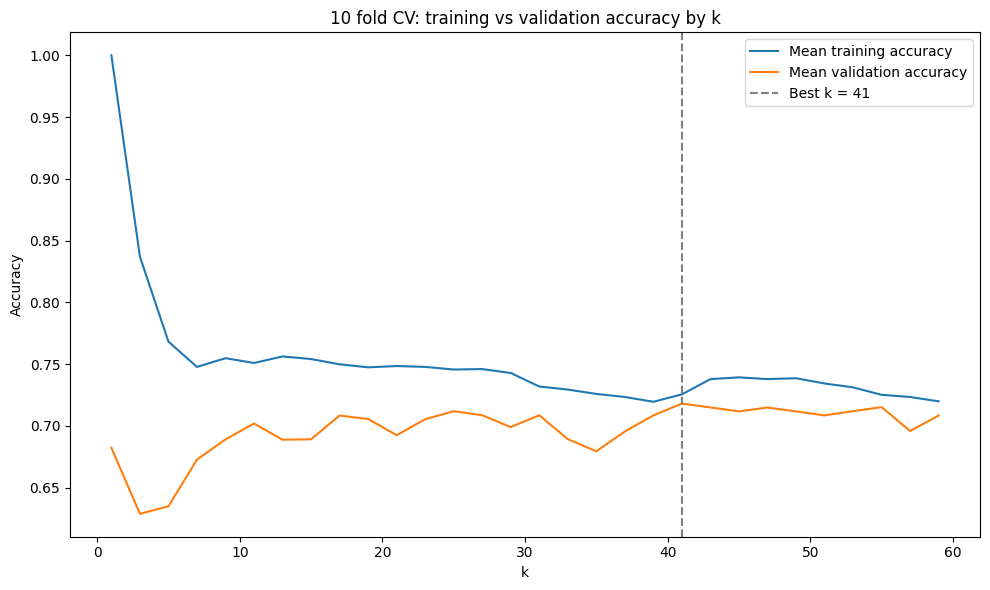

In [56]:
# YOUR CODE
train_scores = []
val_scores = []

for k in k_values:
    knn_pipeline = Pipeline([
        ('prep', preprocessor),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    cv_results = cross_validate(
        knn_pipeline,
        X_train, y_train,
        cv=10,
        return_train_score=True,
    )
    train_scores.append(cv_results["train_score"].mean())
    val_scores.append(cv_results["test_score"].mean())

best_k = k_values[np.argmax(val_scores)]
best_val_accuracy = val_scores[np.argmax(val_scores)]

print(f"Best k: {best_k}")
print(f"Mean validation accuracy: {best_val_accuracy:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(k_values, train_scores, label="Mean training accuracy")
plt.plot(k_values, val_scores, label="Mean validation accuracy")
plt.axvline(best_k, color="gray", linestyle="--", label=f"Best k = {best_k}")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("10 fold CV: training vs validation accuracy by k")
plt.legend()
plt.tight_layout()
plt.show()


>**YOUR ANSWER (Q3.4):** At small values of k, the training accuracy is much higher than the validation accuracy, so the model is overfitting there. As k increases, the training curve falls while the validation curve rises and then plateaus , and the gap between the two lines shrink, which is what we expect as the classifier becomes smoother and less sensitive to single neighbors. For very large k, both curves move closer together, training and validation are nearly the same but not very high, which tells us the model is underfitting. The best k is where validation accuracy peaks.
>
>

### Question 4. Conceptual questions about *k* (2 $\times$ 3 = 6 points)

Answer each in the markdown cell below. You may verify your answers in code first, but the answer cell must explain the *reason*, not just report the value.

1. When `k = 1`, the **training** accuracy is exactly 1.0. Why must this be true &mdash; and why is it not evidence that the model is good? 
2. Suppose you set `k` equal to the number of training samples. What will the model predict for *any* input, and what accuracy would that give on our test set? (Look carefully at the class balance of the training set before answering.) 
3. In terms of **bias** and **variance**, which end of the `k` range is which? 

In [57]:
# Optional: verify your answers to (1) and (2) in code before writing them up.
# YOUR CODE



<!--SOLUTION-->
>**YOUR ANSWER:**
>
>**Q4.1:** When k = 1 the training accuracy is exactly 1. This is true because it points to itself as it's cloest neighbor. So when the model predicts a training sample, it uses that exact sample as its nearest neighbor and predicts its class correctly. This is not evidence that the model is good because it has memorized the training data and will perform worst on unseen data, which leads to model overfitting.
>
>
>**Q4.2:** If we set k equal to the number of training samples, every classification becomes the same class, which will be the majority class in the training data. In our case, the classes are evenly distributed, so it is a 3 way tie in predictions. To break the tie, the KNN classifier will break the tie by choosing the class with the smallest label index, in our case, the affordable class. Therefore, any input will be predicted as affordable.
>
>
>**Q4.3:** When the model overfits, there is low bias and high variance, which is towards the start of the graph about (1-4). Whereas when the model underfits, there is high bias and low variance, which is towards the end of the graph (55-60).
>
>

***
## Part 3: Final Evaluation and Data Story (25 points)

You have cleaned the data and selected `k` using *validation* data. The test set has not been touched. Now &mdash; and **only** now &mdash; you may use it, **once**.

### Question 1. Final evaluation on the test set (3 + 2 + 2 + 3 = 10 points)

1. Build a final pipeline using the **`best_k`** you found in Part 2, Question 3, and fit it on the **full training set**. 
2. Predict on the test set and report the **test accuracy**, alongside the baseline from Part 1. 
3. Display the **confusion matrix** for the test set predictions.
   - Label both the rows and columns with the tier names in the following order:
      `affordable`, `mid`, `luxury`<br>
     **The order matters** because it determines how the rows and columns of the confusion matrix are arranged. Do not use alphabetical ordering. 
   - Hint: Use `confusion_matrix(y_test, y_pred, labels=tiers)`, where `tiers` contains the class names in the required order. Then pass `tiers` as `display_labels` when creating the `ConfusionMatrixDisplay`.
4. In the answer cell: 
   - Is there any tier the model handles noticeably worse than the others?
   - Which pair(s) of classes are confused most often?
   - Is accuracy a sufficient summary of this model's performance? Why or why not?

Baseline accuracy (Part 1): 0.3333
Test accuracy (k=41):   0.6667


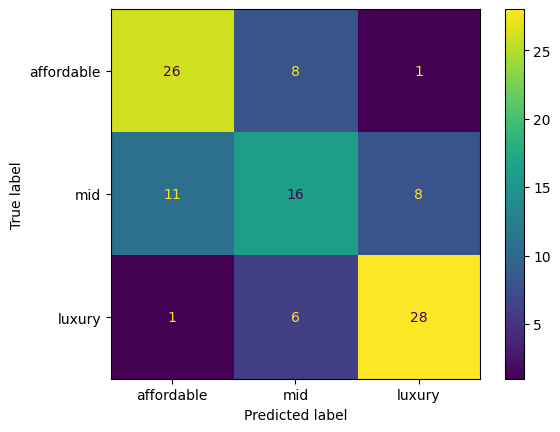

In [58]:
# YOUR CODE
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

tiers = ["affordable", "mid", "luxury"]
baseline_accuracy = 1 / 3  # Part 1: always predict most frequent class

final_pipeline = Pipeline([
    ("prep", preprocessor),
    ("knn", KNeighborsClassifier(n_neighbors=best_k)),
])

model_fit = final_pipeline.fit(X_train, y_train)

y_pred = final_pipeline.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Baseline accuracy (Part 1): {baseline_accuracy:.4f}")
print(f"Test accuracy (k={best_k}):   {test_accuracy:.4f}")

cm = confusion_matrix(y_test, y_pred, labels=tiers)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tiers)
disp.plot()


>**YOUR ANSWER (Q1.4):** The mid tier is handled noticable worse than the other by the model. Mid is being confused the most with being affordable abd luxury. Accuracy is not a sufficient summary of this model's performance because although we had an accuracy of about 66.7% for the best k (k=41), more than half of the mid tier was predicted incorrectly (19/35).
>
>

### Question 2. Your data story (15 points)

Write **200–300 words**, in plain prose, that an interested non-expert could follow. Do not include code. Your response should tell the story of your analysis and address **all four** of the following:

1. **The data and the question:** What is in this dataset, and what question were you trying to answer with it?
2. **Cleaning and preparation:** What did you have to clean, fix, or prepare before modeling? Explain **why each step mattered** for the analysis.
3. **Choosing `k`:** How did you choose the value of `k` for your final model? Explain why you could **not simply choose the value of `k` that gave the highest test accuracy**.
4. **Model performance:** How well does the final model perform compared with a sensible baseline? Describe **where the model performs well and where it fails**, using evidence from your results.

In [59]:
housing_clean

,region,dist_downtown_km,elevation_m,lot_sqft,bedrooms,bathrooms,age_years,living_sqft,price_tier
0,Kaneohe,16.8,49,5608,3,3,29.0,1995.0,mid
1,Kaneohe,17.9,30,5466,3,3,35.0,NaN,mid
2,Honolulu,3.4,0,3979,3,2,33.0,2017.0,mid
3,Honolulu,6.2,25,4769,4,3,38.0,3115.0,luxury
4,Mililani,24.0,96,5322,2,2,41.0,1979.0,affordable
...,...,...,...,...,...,...,...,...,...
415,Mililani,26.8,33,4637,3,2,30.0,1744.0,affordable
416,Honolulu,1.6,28,4453,3,3,70.0,2208.0,luxury
417,Honolulu,3.0,26,4382,3,2,28.0,2685.0,luxury
418,Honolulu,4.4,4,7372,3,3,40.0,2552.0,luxury


>**YOUR ANSWER:** This dataset contains 420 entries of home on Oahu, with various features, including region, dist_downtown_km, elevation_m, lot_sqft, bedrooms, bathrooms, etc. The goal was to predict each home's price tier from the attributes the data contains using a KNN model. The data I had to clean involved the region column having inconsistent capitalization, which would create duplicate columns when using the one-hot encoding. I also had to handle missing values through imputing medians of numerical features on the training data (to avoid data leakage). This mattered because we don't want to drop rows with missing values or ignore missing values since we have a smaller dataset. I also scaled the data so that one feature didn't hold more weight than another which is especially important for KNN classification because KNN relies on distance. I chose k=41 by performing 10 fold cross validation on the training set, picking the value with the best mean validation accuracy. I could not simply choose the value of k that gave the highest test accuracy because that would leak test information into model selection, we want to keep the test set for the final unbiased evaluation after hyperparameters such as k is chosen. The final model performs well above the baseline, the model reached about a 67% accuracy, whereas the baseline was 33%. The model performs not so well in classifying mid classes. A lot of mid homes were being classified as affordable and or luxury. In general, the model performed decently when trying to classify luxury and affordable classes.
>
>